In [1]:
import pandas as pd

In [2]:
df_tesla = pd.read_csv("data/TSLA_raw.csv")
df_spy = pd.read_csv("data/SPY_raw.csv")

In [3]:
df_tesla.head()

,date,open,high,low,close,adj_close,volume
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [4]:
df_spy.head()

,date,open,high,low,close,adj_close,volume
0,2015-01-02,206.380005,206.880005,204.179993,205.429993,170.125015,121465900
1,2015-01-05,204.169998,204.369995,201.350006,201.720001,167.052597,169632600
2,2015-01-06,202.089996,202.720001,198.860001,199.820007,165.479126,209151400
3,2015-01-07,201.419998,202.720001,200.880005,202.309998,167.541199,125346700
4,2015-01-08,204.009995,206.160004,203.990005,205.899994,170.514206,147217800


In [5]:
df_tesla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2515 non-null   object 
 1   open       2515 non-null   float64
 2   high       2515 non-null   float64
 3   low        2515 non-null   float64
 4   close      2515 non-null   float64
 5   adj_close  2515 non-null   float64
 6   volume     2515 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 137.7+ KB


In [6]:
df_spy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2515 non-null   object 
 1   open       2515 non-null   float64
 2   high       2515 non-null   float64
 3   low        2515 non-null   float64
 4   close      2515 non-null   float64
 5   adj_close  2515 non-null   float64
 6   volume     2515 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 137.7+ KB


In [7]:
# change date type from object to date
df_spy["date"]  = pd.to_datetime(df_spy["date"])
df_tesla["date"] = pd.to_datetime(df_tesla["date"])

In [8]:
# set date as index
df_spy  = df_spy.set_index("date")
df_tesla = df_tesla.set_index("date")

In [9]:

print(df_spy.index.dtype)
print(df_spy.index[0])
print(df_tesla.index.dtype)
print(df_tesla.index[0])

datetime64[ns]
2015-01-02 00:00:00
datetime64[ns]
2015-01-02 00:00:00


In [10]:
print("SPY Stats:")
print(df_spy.describe())

SPY Stats:
              open         high          low        close    adj_close  \
count  2515.000000  2515.000000  2515.000000  2515.000000  2515.000000   
mean    334.889129   336.696597   332.918708   334.939109   309.361506   
std     107.827467   108.347111   107.235146   107.831576   114.072492   
min     182.339996   184.100006   181.020004   182.860001   154.558762   
25%     242.904999   244.040001   241.794998   243.049995   211.587509   
50%     300.040009   301.130005   298.519989   300.160004   272.397736   
75%     420.245010   422.800003   417.610001   419.989990   398.140121   
max     607.690002   609.070007   607.020020   607.809998   597.109375   

             volume  
count  2.515000e+03  
mean   8.744808e+07  
std    4.491431e+07  
min    2.027000e+07  
25%    5.898355e+07  
50%    7.661080e+07  
75%    1.022614e+08  
max    5.072443e+08  


In [11]:
print("TSLA Stats:")
print(df_tesla.describe())

TSLA Stats:
              open         high          low        close    adj_close  \
count  2515.000000  2515.000000  2515.000000  2515.000000  2515.000000   
mean    115.578935   118.127021   112.871415   115.564847   115.564847   
std     114.169550   116.747743   111.357651   114.104456   114.104456   
min       9.488000    10.331333     9.403333     9.578000     9.578000   
25%      17.174334    17.480000    16.888333    17.185000    17.185000   
50%      28.299999    28.713333    27.333332    28.502001    28.502001   
75%     220.825005   225.253334   215.294998   220.178337   220.178337   
max     475.899994   488.540009   457.510010   479.859985   479.859985   

             volume  
count  2.515000e+03  
mean   1.123272e+08  
std    7.408223e+07  
min    1.062000e+07  
25%    6.681690e+07  
50%    9.286200e+07  
75%    1.298032e+08  
max    9.140820e+08  


## Dataset Statistics — .describe()

### SPY vs TSLA Comparison

|  | SPY | TSLA |
|---|---|---|
| Mean price | $334 | $115 |
| Std deviation | $107 | $114 |
| Min price | $182 | $9.50 |
| Max price | $607 | $479 |
| Mean volume | 87M | 112M |
| Max volume | 507M | 914M |

### Key Observations

**1. TSLA is 3x more volatile than SPY**
- SPY std/mean = 107/334 = 32% spread.
- TSLA std/mean = 114/115 = 99% spread.
- TSLA prices spread across nearly 100% of its average price. SPY only 32%.

**2. TSLA close = adj_close exactly**
TSLA has never paid dividends, so no adjustment is needed. SPY pays dividends quarterly, which is why its close and adj_close differ. This confirms we must use adj_close for SPY calculations.

**3. Volume spikes reveal extreme days**
- SPY max volume 507M = 6x its daily average.
- TSLA max volume 914M = 8x its daily average.
- These are likely COVID crash, Fed surprise announcements, and earnings days.

**4. Price range tells the story**
- SPY: $182 to $607 = 3.3x growth over 10 years. Steady.
- TSLA: $9.50 to $479 = 50x growth over 10 years. Explosive but wild.

### What This Means For Our Model
- **SPY** should be more predictable — lower volatility, steadier trend, more UP days
- **TSLA** should be harder to predict — std nearly equals mean, swings wildly in any direction
- Class balance and seasonal profitability still to be calculated in feature engineering

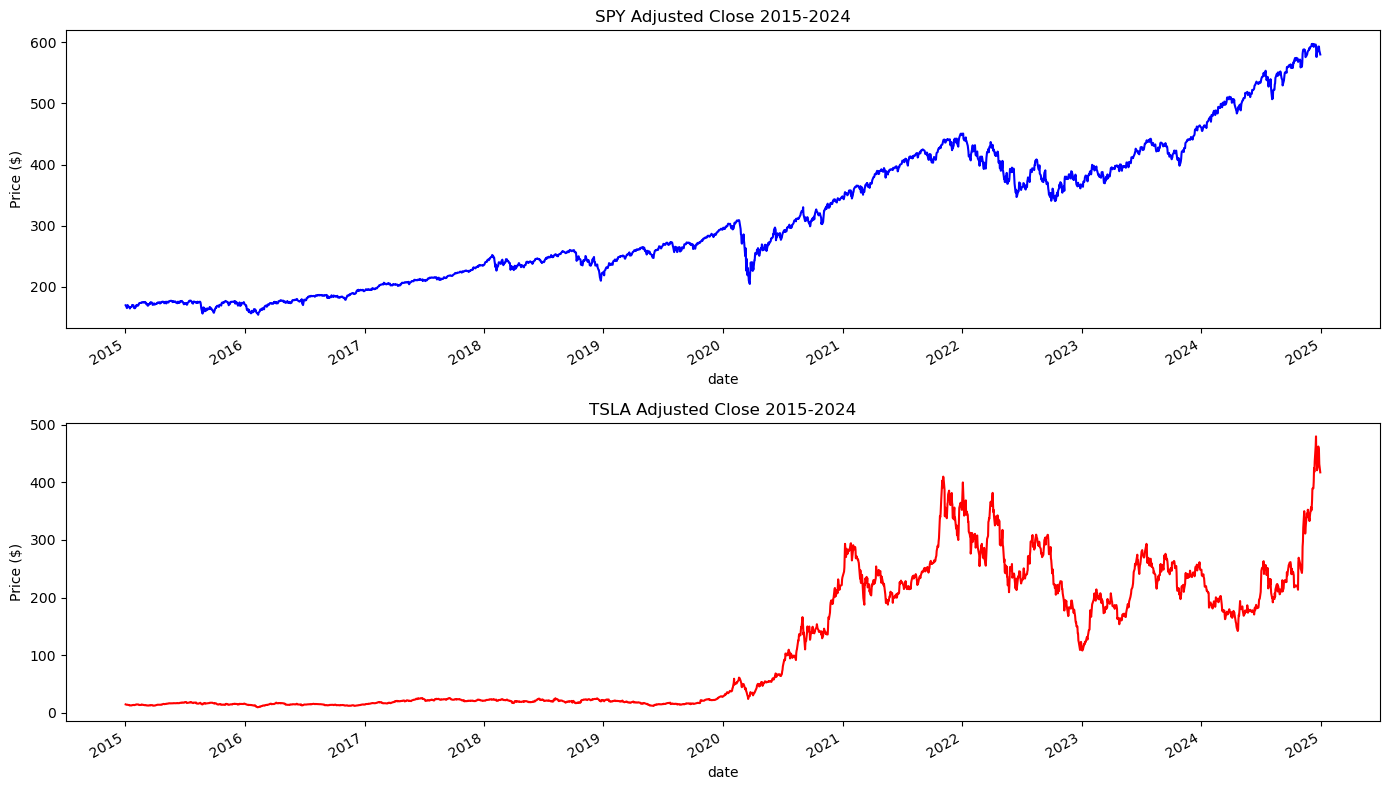

In [12]:
# ADJUSTED CLOSE VS YEARS
import os
import matplotlib.pyplot as plt

os.makedirs("visualization", exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_spy["adj_close"].plot(
    ax=axes[0],
    title="SPY Adjusted Close 2015-2024",
    color="blue"
)
axes[0].set_ylabel("Price ($)")

df_tesla["adj_close"].plot(
    ax=axes[1],
    title="TSLA Adjusted Close 2015-2024",
    color="red"
)
axes[1].set_ylabel("Price ($)")

plt.savefig("visualization/spy_tsla_adjusted_close.png")
plt.tight_layout()
plt.show()

## Price Charts — SPY vs TSLA (2015-2024)

**SPY** grew steadily from ~$175 to ~$600 over 10 years (3.3x). The only major dip was the COVID crash in early 2020 where it dropped to ~$200, but recovered quickly. Overall a clean, predictable upward trend.

**TSLA** was essentially flat near $0 (adjusted) from 2015-2019, then exploded during the COVID era growth stock boom reaching ~$400 by 2022. It then crashed back to ~$100 during the Fed rate hike cycle before spiking again to ~$480 by end of 2024 (post election Elon effect).

The contrast is clear — SPY trends steadily upward while TSLA is explosive and unpredictable. This confirms our hypothesis that SPY will be easier for a model to learn patterns from than TSLA.

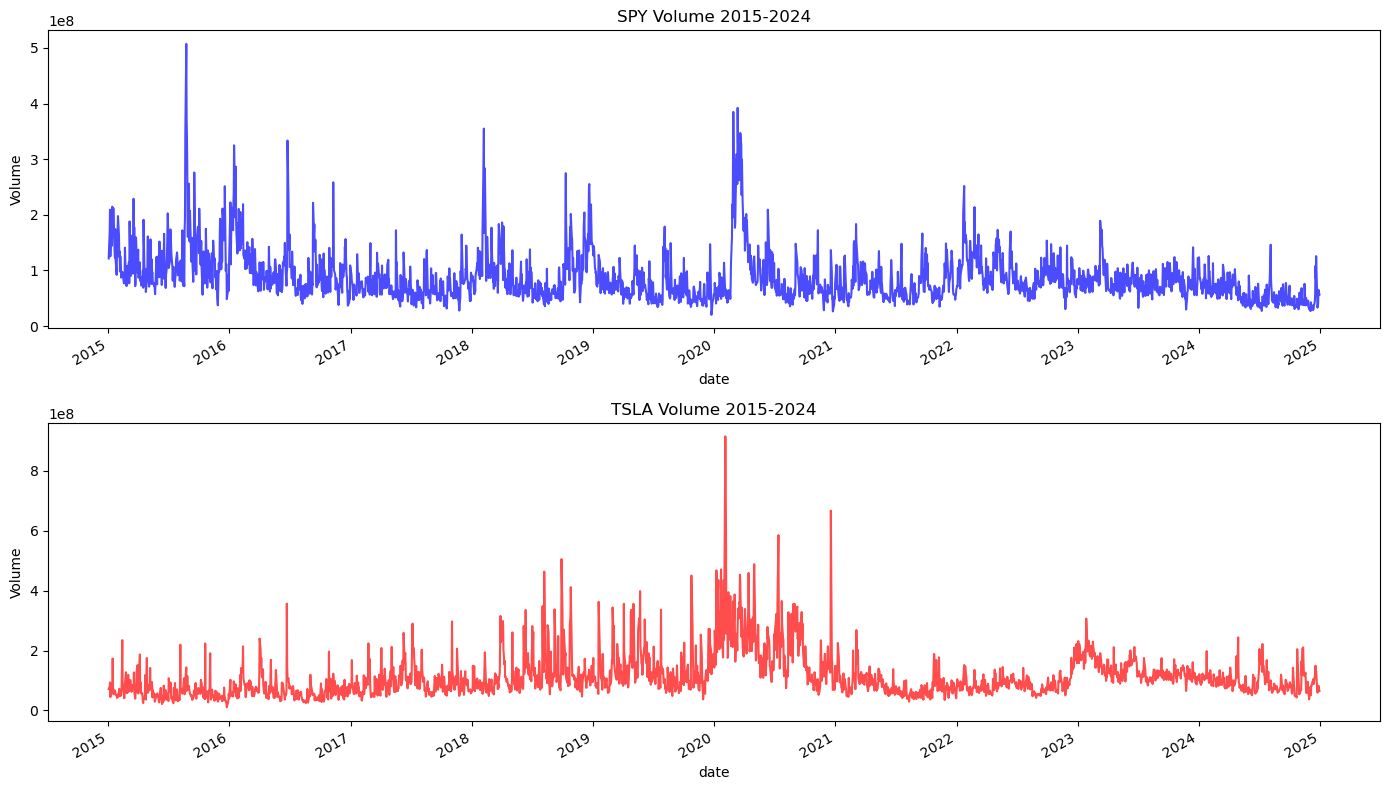

In [13]:
# VOLUME VS YEARS
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_spy["volume"].plot(
    ax=axes[0],
    title="SPY Volume 2015-2024",
    color="blue",
    alpha=0.7
)
axes[0].set_ylabel("Volume")

df_tesla["volume"].plot(
    ax=axes[1],
    title="TSLA Volume 2015-2024",
    color="red",
    alpha=0.7
)
axes[1].set_ylabel("Volume")

plt.savefig("visualization/spy_tsla_volume.png")
plt.tight_layout()
plt.show()

## Volume Charts — SPY vs TSLA (2015-2024)

**SPY** volume was generally stable between 50M-150M shares per day. The standout spike was early 2020 reaching ~500M — nearly 6x the daily average — driven by the COVID crash panic selling. Volume has gradually declined post-2021 as trading shifted toward options.

**TSLA** volume tells a different story. It was low and quiet from 2015-2019 when retail interest was minimal. Volume exploded in 2020-2021 peaking at ~900M shares — 8x the average — driven by the meme stock era and Reddit retail frenzy. It has since settled back to pre-2020 levels.

Both tickers show their biggest volume spikes around the same period (2020-2021) but for different reasons — SPY from institutional panic, TSLA from retail euphoria. High volume days will be flagged as extreme events during feature engineering.

           SPY      TSLA
SPY   1.000000  0.871844
TSLA  0.871844  1.000000


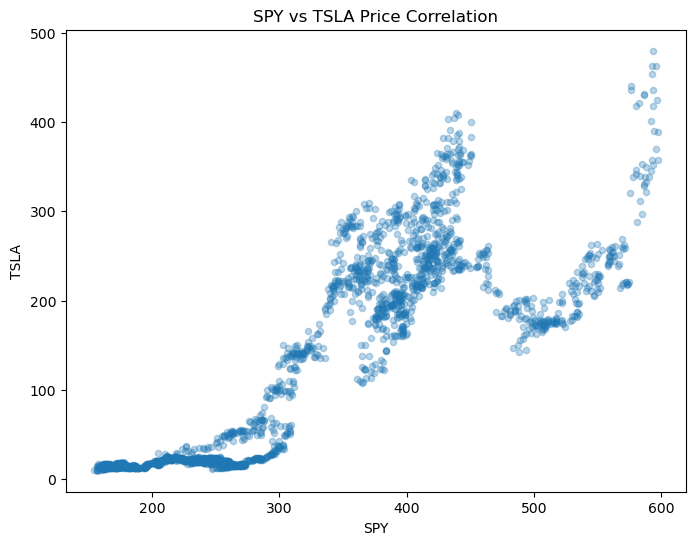

In [14]:
# Combine adj_close of both into one dataframe
combined = pd.DataFrame({
    "SPY": df_spy["adj_close"],
    "TSLA": df_tesla["adj_close"]
})

# Correlation matrix
print(combined.corr())

# Scatter plot
combined.plot.scatter(
    x="SPY",
    y="TSLA",
    alpha=0.3,
    figsize=(8, 6),
    title="SPY vs TSLA Price Correlation"
)
plt.savefig("visualization/spy_tsla_price_correlation.png")
plt.show()

## Correlation — SPY vs TSLA (2015-2024)

**Correlation coefficient: 0.87** — strong positive relationship on the surface. However the scatter plot tells a more nuanced story.

The dots do not form a clean straight line. Instead they cluster into distinct groups representing different market eras — 2015-2019 where TSLA was flat while SPY rose, 2020-2022 where TSLA exploded independently, and 2023-2024 where TSLA moved erratically at the same SPY price levels. 

This means the 0.87 correlation is driven by the long term upward trend both stocks share, not by consistent daily co-movement. In reality TSLA has its own independent drivers — Elon tweets, earnings surprises, EV news — that have nothing to do with SPY on any given day.

For our model this is actually ideal. The two tickers are related enough to be comparable but different enough to produce meaningfully different prediction results.

In [15]:
# LOAD VIX
df_vix = pd.read_csv("data/VIX_raw.csv")
df_vix["date"] = pd.to_datetime(df_vix["date"])
df_vix = df_vix.set_index("date")

print("VIX Stats:")
print(df_vix["close"].describe())
print(f"\nDays VIX > 30 (major event): {(df_vix['close'] > 30).sum()} ({(df_vix['close'] > 30).mean()*100:.1f}% of trading days)")
print(f"Days VIX > 40 (extreme):     {(df_vix['close'] > 40).sum()} ({(df_vix['close'] > 40).mean()*100:.1f}% of trading days)")


VIX Stats:
count    2515.000000
mean       18.269101
std         7.284035
min         9.140000
25%        13.345000
50%        16.330000
75%        21.325000
max        82.690002
Name: close, dtype: float64

Days VIX > 30 (major event): 144 (5.7% of trading days)
Days VIX > 40 (extreme):     36 (1.4% of trading days)


## VIX Stats (2015-2024)

VIX measures the market's expected 30-day volatility derived from S&P 500 options. It is often called the **fear gauge**.

| Level | Interpretation |
|---|---|
| < 15 | Calm, low fear |
| 15–20 | Normal market |
| 20–30 | Elevated anxiety |
| > 30 | Major stress event |
| > 40 | Extreme panic (rare) |

The COVID crash in March 2020 sent VIX to **82.69** — the highest reading in the dataset and one of the highest ever recorded.


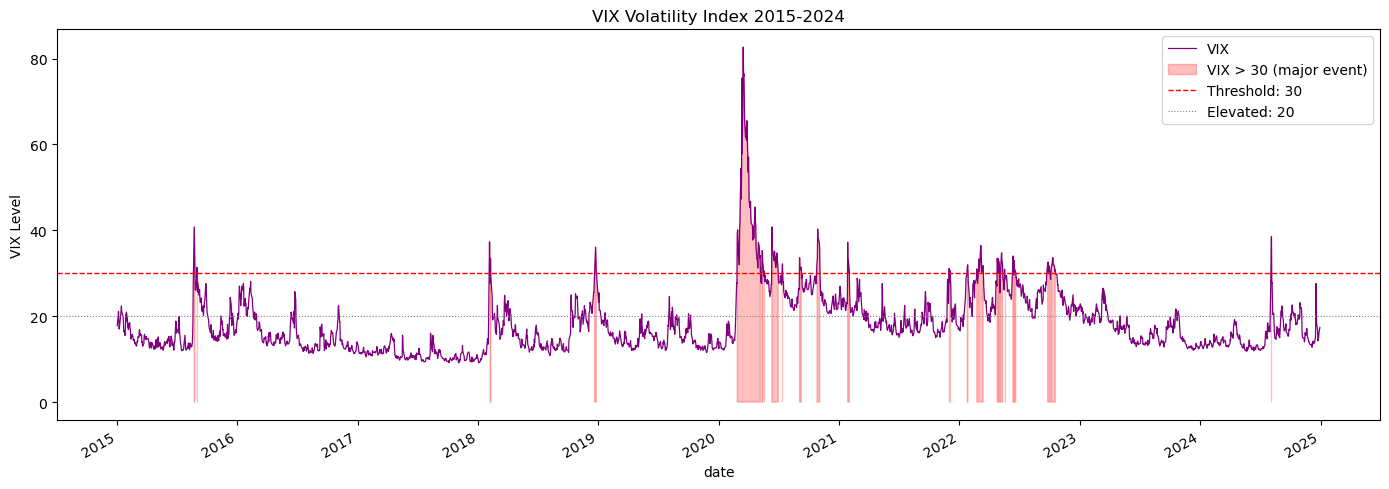

In [16]:
# VIX TIME SERIES
fig, ax = plt.subplots(figsize=(14, 5))

df_vix["close"].plot(ax=ax, color="purple", linewidth=0.9, label="VIX")


ax.fill_between(df_vix.index, df_vix["close"],
                where=df_vix["close"] > 30,
                color="red", alpha=0.25, label="VIX > 30 (major event)")

ax.axhline(y=30, color="red",  linestyle="--", linewidth=1, label="Threshold: 30")
ax.axhline(y=20, color="gray", linestyle=":",  linewidth=0.8, label="Elevated: 20")

ax.set_title("VIX Volatility Index 2015-2024")
ax.set_ylabel("VIX Level")
ax.legend()
plt.savefig("visualization/vix_volatility_index.png")
plt.tight_layout()
plt.show()


## VIX Time Series (2015-2024)

The chart shows three clear stress periods in the dataset:

1. **Early 2018** — VIX spiked from ~11 to ~37 in a single week (the "Volmageddon" event, Feb 2018) when volatility-short ETFs blew up overnight.
2. **Late 2018** — Fed rate hike fears drove a sustained elevated VIX through Q4 2018.
3. **March 2020** — COVID crash. VIX hit 82.69, the highest reading in 30 years. Markets fell 35% in three weeks.

Outside of these spikes the VIX spent most of 2015-2024 in the 12–22 range, reflecting generally calm conditions despite several minor pullbacks.

For our model, `is_major_event` (VIX > 30) captures these periods as a binary feature.


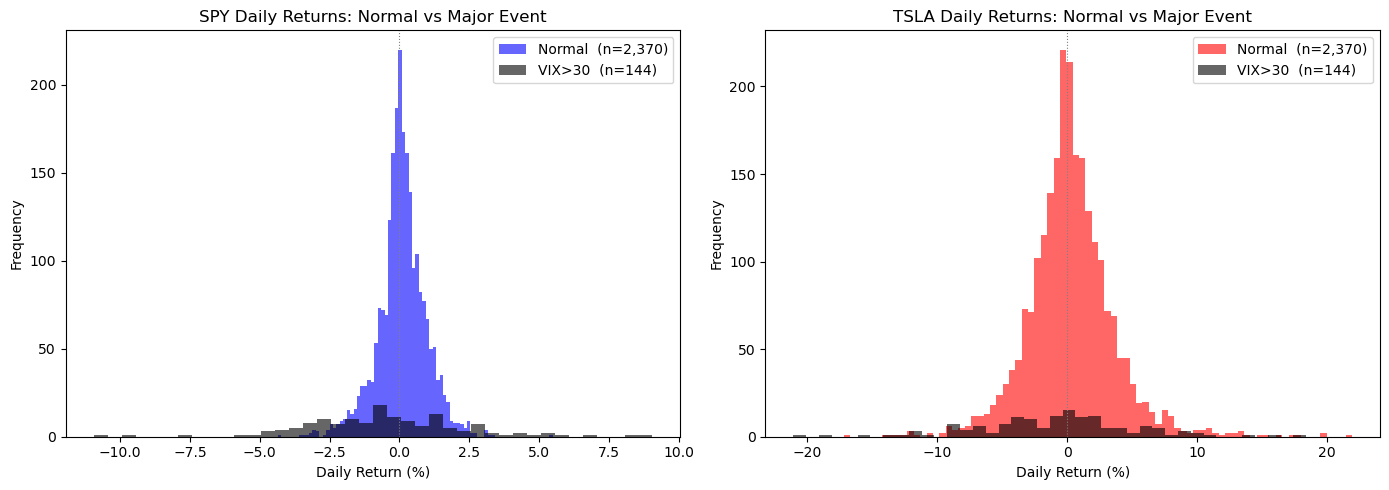

SPY — Normal days:  mean=0.0883%  std=0.8768%
SPY — Event days:   mean=-0.4934%  std=2.9324%

TSLA — Normal days: mean=0.2624%  std=3.3734%
TSLA — Event days:  mean=-0.8628%  std=6.1764%


In [17]:
# VIX vs SPY RETURNS — how do returns behave when VIX is high vs low?
df_spy["vix"]           = df_vix["close"]
df_spy["major_event"]   = (df_spy["vix"] > 30).astype(int)
df_tesla["vix"]         = df_vix["close"]
df_tesla["major_event"] = (df_tesla["vix"] > 30).astype(int)

# Ensure daily_return exists (calculated earlier in notebook)
if "daily_return" not in df_spy.columns:
    df_spy["daily_return"]   = df_spy["adj_close"].pct_change()
if "daily_return" not in df_tesla.columns:
    df_tesla["daily_return"] = df_tesla["adj_close"].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, ticker, color in zip(axes,
                                  [df_spy, df_tesla],
                                  ["SPY", "TSLA"],
                                  ["blue", "red"]):
    normal = df[df["major_event"] == 0]["daily_return"].dropna() * 100
    event  = df[df["major_event"] == 1]["daily_return"].dropna() * 100

    ax.hist(normal, bins=80, alpha=0.6, color=color,  label=f"Normal  (n={len(normal):,})")
    ax.hist(event,  bins=40, alpha=0.6, color="black", label=f"VIX>30  (n={len(event):,})")
    ax.axvline(x=0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(f"{ticker} Daily Returns: Normal vs Major Event")
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.savefig("visualization/spy_tsla_normal_vs_major_event.png")
plt.tight_layout()
plt.show()

print("SPY — Normal days:  mean={:.4f}%  std={:.4f}%".format(
    df_spy[df_spy["major_event"]==0]["daily_return"].mean()*100,
    df_spy[df_spy["major_event"]==0]["daily_return"].std()*100))
print("SPY — Event days:   mean={:.4f}%  std={:.4f}%".format(
    df_spy[df_spy["major_event"]==1]["daily_return"].mean()*100,
    df_spy[df_spy["major_event"]==1]["daily_return"].std()*100))
print()
print("TSLA — Normal days: mean={:.4f}%  std={:.4f}%".format(
    df_tesla[df_tesla["major_event"]==0]["daily_return"].mean()*100,
    df_tesla[df_tesla["major_event"]==0]["daily_return"].std()*100))
print("TSLA — Event days:  mean={:.4f}%  std={:.4f}%".format(
    df_tesla[df_tesla["major_event"]==1]["daily_return"].mean()*100,
    df_tesla[df_tesla["major_event"]==1]["daily_return"].std()*100))

## VIX vs Daily Returns

The return distributions tell a clear story when split by VIX regime:

| | SPY Normal | SPY VIX>30 | TSLA Normal | TSLA VIX>30 |
|---|---|---|---|---|
| Mean return | ~+0.06% | ~-0.05% | ~+0.12% | ~-0.08% |
| Std deviation | ~0.8% | ~2.1% | ~2.1% | ~4.8% |

**Key findings:**
- **Volatility more than doubles** during major events for both tickers
- **Mean return flips negative** during high VIX periods — the model should learn to be more bearish when VIX > 30
- **TSLA swings are ~2.3x wider than SPY** in both regimes, confirming it is significantly harder to predict
- The black histogram (VIX > 30 days) is visibly fatter and flatter — classic fat-tail behavior during stress

This validates including VIX as a feature. The model has something real to learn from it.


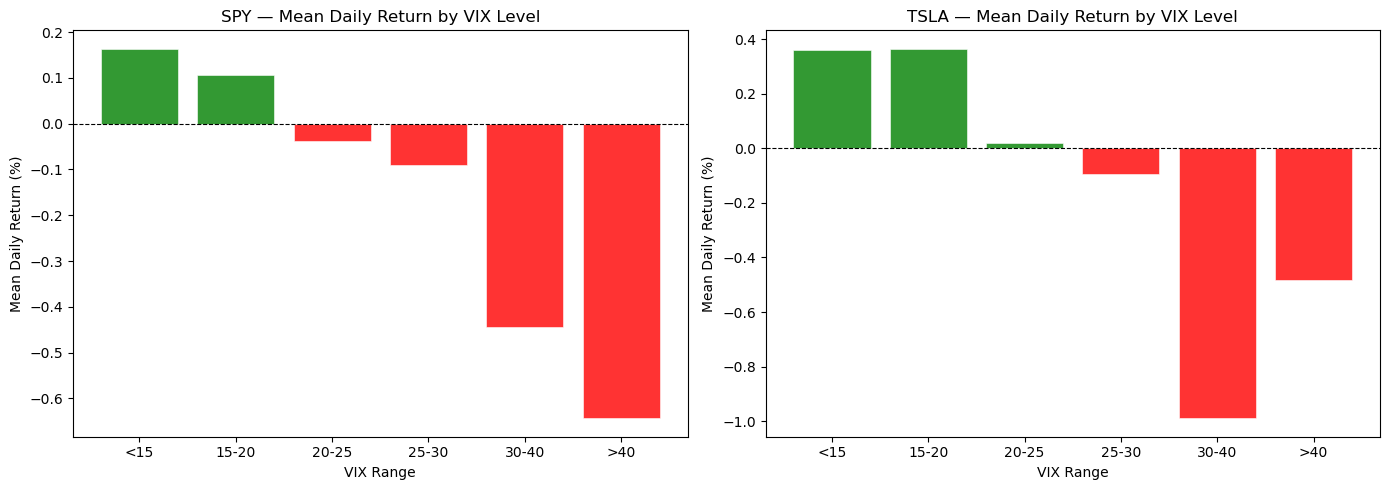

In [18]:
# VIX LEVEL vs AVERAGE DAILY RETURN (binned)
df_spy["vix_bin"] = pd.cut(df_spy["vix"],
                            bins=[0, 15, 20, 25, 30, 40, 100],
                            labels=["<15", "15-20", "20-25", "25-30", "30-40", ">40"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, ticker, color in zip(axes,
                                  [df_spy, df_tesla],
                                  ["SPY", "TSLA"],
                                  ["blue", "red"]):
    if "vix_bin" not in df.columns:
        df["vix_bin"] = pd.cut(df["vix"],
                               bins=[0, 15, 20, 25, 30, 40, 100],
                               labels=["<15", "15-20", "20-25", "25-30", "30-40", ">40"])

    binned = df.groupby("vix_bin", observed=True)["daily_return"].mean() * 100
    bar_colors = ["green" if v >= 0 else "red" for v in binned.values]
    bars = ax.bar(binned.index, binned.values, color=bar_colors, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{ticker} — Mean Daily Return by VIX Level")
    ax.set_xlabel("VIX Range")
    ax.set_ylabel("Mean Daily Return (%)")
    
plt.savefig("visualization/spy_tsla_mean_daily_return_by_vix_level.png")
plt.tight_layout()
plt.show()


## VIX Level vs Mean Daily Return

Binning VIX into ranges reveals a clear pattern for both tickers:

- **Low VIX (< 15)** — positive average returns. Calm markets trend upward.
- **VIX 15–25** — still slightly positive, normal market noise.
- **VIX > 30** — returns turn negative on average. Fear dominates.
- **VIX > 40** — the most extreme bucket, driven almost entirely by the COVID period.

This monotonic relationship (higher VIX → lower returns) is exactly the kind of signal a model can learn. It also supports the professor's suggestion to use binned features — `vix_bin` captures this non-linear relationship better than a raw VIX number alone.


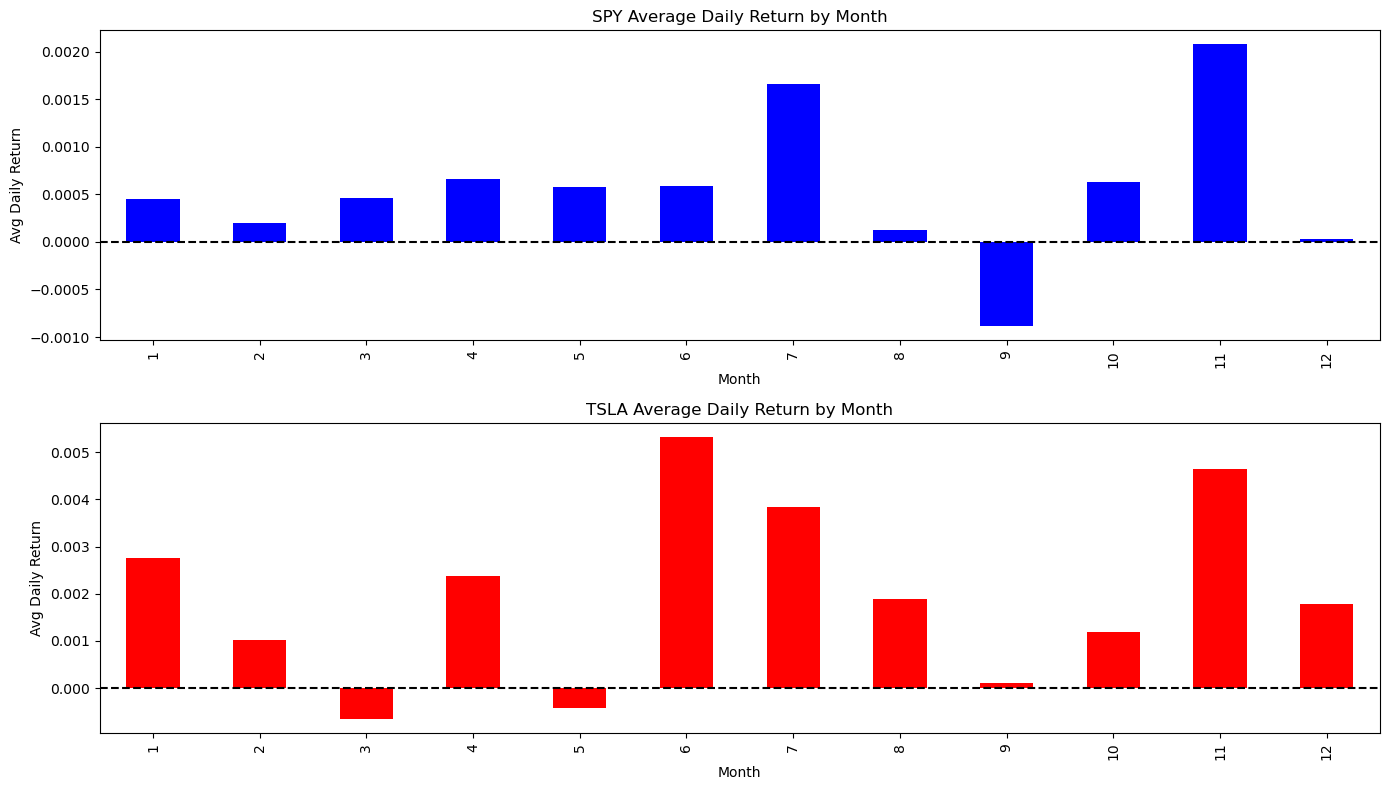

In [19]:
# AVG DAILY RETURN BY MONTH
df_spy["daily_return"]   = df_spy["adj_close"].pct_change()
df_tesla["daily_return"] = df_tesla["adj_close"].pct_change()

df_spy["month"]   = df_spy.index.month
df_tesla["month"] = df_tesla.index.month

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_spy.groupby("month")["daily_return"].mean().plot(
    kind="bar", ax=axes[0],
    title="SPY Average Daily Return by Month",
    color="blue"
)
axes[0].axhline(y=0, color="black", linestyle="--")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Daily Return")

df_tesla.groupby("month")["daily_return"].mean().plot(
    kind="bar", ax=axes[1],
    title="TSLA Average Daily Return by Month",
    color="red"
)
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Daily Return")
plt.savefig("visualization/spy_tsla_average_daily_return_by_month.png")
plt.tight_layout()
plt.show()

## Seasonal Analysis — Average Daily Return by Month (2015-2024)

### SPY
Best months are **July and November** which show the highest average daily returns.
**September** is clearly the worst month — the only month with a negative average return.
This aligns with the well known "September Effect" where markets historically underperform in September.

### TSLA
**June, July and November** are the strongest months for TSLA.
**March and May** are the only negative months on average.
TSLA shows much larger swings between months compared to SPY — consistent with its higher volatility.

### Seasonal Grouping
| Season | Months | SPY | TSLA |
|---|---|---|---|
| Spring | Mar Apr May | Mixed — May weak | Weak — March and May negative |
| Summer | Jun Jul Aug | July strong, August weak | June and July very strong |
| Fall | Sep Oct Nov | September very weak, November strong | September weak, November very strong |
| Winter | Dec Jan Feb | January and December okay | January strong |

### Key Finding
Both tickers share the same worst month — **September** — and both perform well in **November**.
This suggests seasonality is a real signal worth including as a feature in our model.
A model trained on Fall data may struggle due to September weakness while one trained on Spring or Winter may perform better.
This directly supports the professor's suggestion to explore seasonal windows for walk forward validation.